In [1]:
import pandas as pd

sentiment_df = pd.read_csv("fear_greed_index.csv")
historical_df =pd.read_csv("historical_data.csv")

In [2]:
historical_df.shape
historical_df.info()
historical_df.isnull().sum()
historical_df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

0

In [3]:
print(sentiment_df.shape)

sentiment_df.info()

sentiment_df.isnull().sum()

sentiment_df.duplicated().sum()

(2644, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


0

In [4]:
historical_df['Timestamp IST'] = pd.to_datetime(
    historical_df['Timestamp IST'], 
    format='%d-%m-%Y %H:%M'
)

In [5]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

In [6]:
historical_df['date'] = historical_df['Timestamp IST'].dt.normalize()

In [7]:
sentiment_df['date'] = sentiment_df['date'].dt.normalize()

In [8]:
merged_df = historical_df.merge(
    sentiment_df,
    on='date',
    how='left'
)

In [9]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [10]:
merged_df['classification'].isnull().sum()

6

In [11]:
merged_df[merged_df['classification'].isnull()].drop_duplicates()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
727,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.8330,10000.00,28330.00,BUY,2024-10-26 04:44:00,-32797.51,Close Short,11655.000000,0x4da9426d2bf6ec027d8404152f9bad02010700c745eb...,40671411386,False,2.719680,8.350000e+13,1.730000e+12,2024-10-26,NaN,NaN,NaN
728,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.7110,10797.51,29272.05,BUY,2024-10-26 04:52:00,-22797.51,Close Short,13901.794130,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671438761,False,2.810115,3.230000e+14,1.730000e+12,2024-10-26,NaN,NaN,NaN
729,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,6908.33,17884.98,BUY,2024-10-26 04:52:00,-12000.00,Close Short,9737.981968,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671466136,False,1.716957,1.070000e+15,1.730000e+12,2024-10-26,NaN,NaN,NaN
730,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,529.39,1370.54,BUY,2024-10-26 04:52:00,-5091.67,Close Short,746.228144,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671466136,False,0.131570,8.770000e+14,1.730000e+12,2024-10-26,NaN,NaN,NaN
731,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,38.65,100.06,BUY,2024-10-26 04:52:00,-4562.28,Close Short,54.481040,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671466136,False,0.009605,9.820000e+14,1.730000e+12,2024-10-26,NaN,NaN,NaN
732,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,4523.63,11711.23,BUY,2024-10-26 04:53:00,-4523.63,Close Short,6376.508848,0x39ce7efcc1773fd0eec704152fbcb4010100c8beadd4...,40671466136,False,1.124277,9.360000e+14,1.730000e+12,2024-10-26,NaN,NaN,NaN


In [12]:
# 1. Ensure data is chronologically ordered before filling
merged_df = merged_df.sort_values(by='Timestamp IST')

In [13]:
# Forward fill without a limit to cover all consecutive missing rows
merged_df['classification'] = merged_df['classification'].ffill()
merged_df['value'] = merged_df['value'].ffill()

# Check the remaining missing values again
print(f"Remaining missing values: {merged_df['classification'].isnull().sum()}")

#In merged dataset There were 6 missing values handled via forward-fill.

Remaining missing values: 0


In [14]:
# Group by date and account, then sum the Closed PnL
daily_pnl = merged_df.groupby(['date', 'Account'])['Closed PnL'].sum().reset_index(name='Daily Total PnL')
display(daily_pnl.head())

,date,Account,Daily Total PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Group by account and sum the total realized PnL
pnl_per_account = merged_df.groupby('Account')['Closed PnL'].sum().reset_index(name='Total PnL')

# Sort the values from highest profit to lowest for better readability
pnl_per_account = pnl_per_account.sort_values(by='Total PnL', ascending=False)

# Display the final dataframe
display(pnl_per_account.tail())

,Account,Total PnL
18,0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,14900.443047
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,14456.919336
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-31203.599986
2,0x271b280974205ca63b716753467d5a371de622ab,-70436.191318
19,0x8170715b3b381dffb7062c0298972d4727a0a63b,-167621.124781


In [17]:
# Filter for closed trades
valid_trades = merged_df[(merged_df['Closed PnL'].notnull()) & (merged_df['Closed PnL'] != 0)]

# Overall Win Rate
overall_win_rate = (valid_trades['Closed PnL'] > 0).mean() * 100
print(f"Overall Win Rate: {overall_win_rate:.2f}%")

# Win Rate & Average Trade Size per Account
# Grouping with enhanced statistical rigor
account_metrics = valid_trades.assign(Is_Win=valid_trades['Closed PnL'] > 0).groupby('Account').agg(
    Win_Rate_Pct=('Is_Win', lambda x: x.mean() * 100),
    Total_Trades=('Closed PnL', 'count'),
    Mean_Trade_Size=('Size USD', 'mean'),
    Median_Trade_Size=('Size USD', 'median') # The true "typical" trade size
).reset_index()

display(account_metrics.head())

Overall Win Rate: 83.20%


,Account,Win_Rate_Pct,Total_Trades,Mean_Trade_Size,Median_Trade_Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,79.272517,1732,17435.058811,2000.070
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,77.364378,4166,1454.128135,397.230
2,0x271b280974205ca63b716753467d5a371de622ab,71.561917,1607,10563.420199,1391.560
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,86.207915,6772,507.390103,144.275
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,81.747573,2060,2508.635146,991.945


C:\Users\ambar\AppData\Local\Temp\ipykernel_9428\1209016461.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


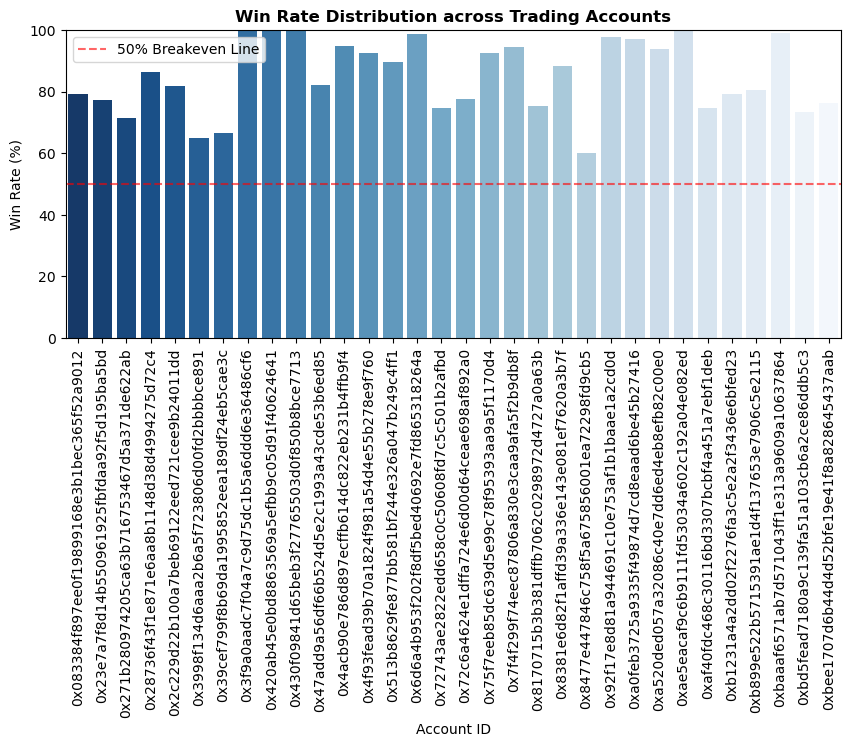

In [18]:
# Visualization: Win Rate per Account
plt.figure(figsize=(10, 4))

# Added hue='Account' and legend=False to fix the FutureWarning
sns.barplot(data=account_metrics, x='Account', y='Win_Rate_Pct', hue='Account', palette='Blues_r', legend=False)
plt.axhline(50, color='red', linestyle='--', alpha=0.6, label='50% Breakeven Line')
plt.title('Win Rate Distribution across Trading Accounts', fontsize=12, fontweight='bold')
plt.ylabel('Win Rate (%)')
plt.xlabel('Account ID')
plt.ylim(0, 100)
plt.xticks(rotation=90) 
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Strictly count opening positions to avoid double-counting the closures
open_longs = merged_df['Direction'].str.contains('Open Long', case=False, na=False).sum()
open_shorts = merged_df['Direction'].str.contains('Open Short', case=False, na=False).sum()

if open_shorts > 0:
    long_short_ratio = open_longs / open_shorts
    print(f"True Long/Short Ratio: {long_short_ratio:.2f}")

True Long/Short Ratio: 1.26


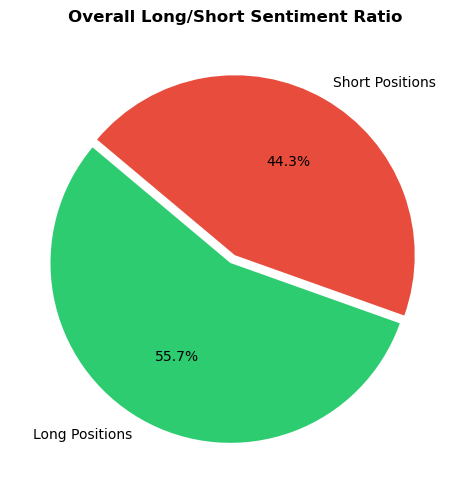

In [20]:
# Visualization: Long vs Short Market Exposure
plt.figure(figsize=(5, 5))
plt.pie(
    [open_longs, open_shorts], 
    labels=['Long Positions', 'Short Positions'], 
    colors=['#2ecc71', '#e74c3c'], 
    autopct='%1.1f%%', 
    startangle=140,
    explode=(0.05, 0)
)
plt.title('Overall Long/Short Sentiment Ratio', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Count total trades AND unique accounts trading that day
daily_activity = merged_df.groupby('date').agg(
    Total_Executions=('Account', 'size'),
    Unique_Active_Traders=('Account', 'nunique')
).reset_index()

display(daily_activity.tail())

,date,Total_Executions,Unique_Active_Traders
475,2025-04-27,337,9
476,2025-04-28,1379,8
477,2025-04-29,2243,7
478,2025-04-30,1113,8
479,2025-05-01,1230,11


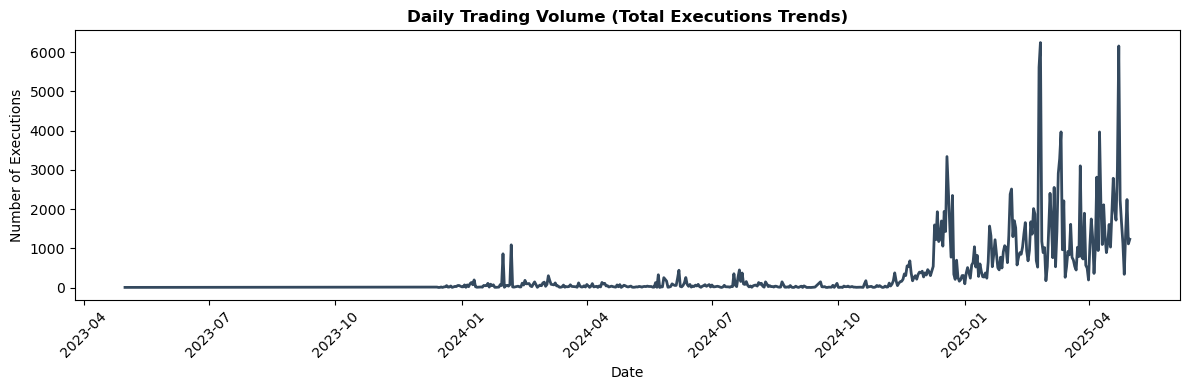

In [22]:
# Visualization: Daily Execution Volume over Time
plt.figure(figsize=(12, 4))
sns.lineplot(data=daily_activity, x='date', y='Total_Executions', color='#34495e', linewidth=2)
plt.title('Daily Trading Volume (Total Executions Trends)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Executions')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
# 1. Calculate the proxy margin per account as a simple Series
proxy_margin_series = merged_df.groupby('Account')['Size USD'].max() / 5

# 2. Map this margin back to the main dataframe so every row has its account's margin
# This avoids the complex alignment error that caused the NaNs
merged_df['Proxy_Margin'] = merged_df['Account'].map(proxy_margin_series)

# 3. Calculate Leverage: Size / Margin
# We use .fillna(0) to handle any remaining gaps, then divide
merged_df['Proxy_Leverage'] = merged_df['Size USD'] / merged_df['Proxy_Margin'].replace(0, 1)

# 4. Final check
leverage_stats = merged_df['Proxy_Leverage'].describe()
print("--- Proxy Leverage Statistics ---")
print(leverage_stats.to_string())

--- Proxy Leverage Statistics ---
count    211224.000000
mean          0.081290
std           0.248045
min           0.000000
25%           0.003846
50%           0.015927
75%           0.060850
max           5.000000


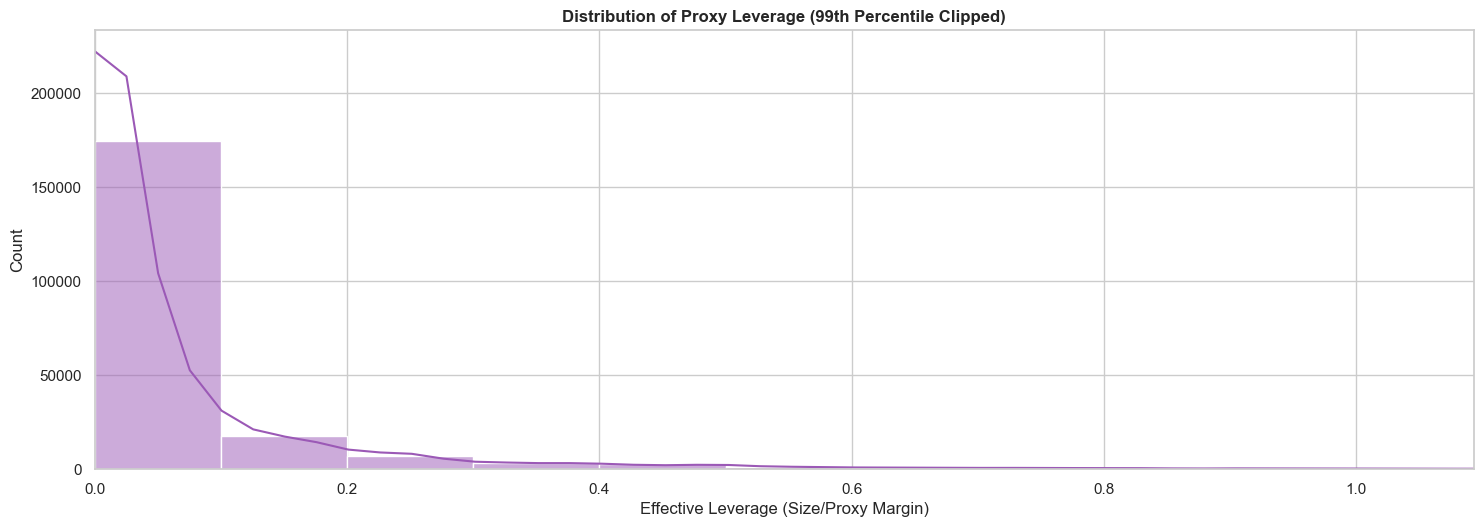

In [24]:
# Visualization: Leverage Distribution
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2)
ax3 = fig.add_subplot(gs[1, :])
sns.histplot(merged_df['Proxy_Leverage'].dropna(), bins=50, kde=True, color='#9b59b6', ax=ax3)
ax3.set_title('Distribution of Proxy Leverage (99th Percentile Clipped)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Effective Leverage (Size/Proxy Margin)')
ax3.set_xlim(0, merged_df['Proxy_Leverage'].quantile(0.99)) # Keeps chart readable by removing extreme outliers

plt.tight_layout()
plt.show()

In [25]:
# Save the cleaned and merged dataframe to a CSV file 
merged_df.to_csv('cleaned_trading_data.csv', index=False)
print("Data successfully saved to 'cleaned_trading_data.csv'")

Data successfully saved to 'cleaned_trading_data.csv'


# Executive Summary: Trading Data Analysis

## Overview

The trading datasets were cleaned, validated, aligned, and analyzed to evaluate overall platform activity and individual account performance. A structured data preparation workflow ensured consistency, reliability, and reproducibility throughout the analysis.

## Data Preparation and Processing

* **Dataset Integration:** Both datasets were merged and synchronized at the **daily level** to enable consistent time-series analysis.
* **Data Quality:** Missing values in the classification and value-related fields were handled using **forward-fill (FFill)** imputation, preserving chronological consistency.
* **Data Integrity:** The final dataset contains **211,224 trading records**. All missing values in critical analytical fields were successfully resolved, resulting in **zero remaining null values**.

## Analytical Methodology

### Win Rate Analysis

Win rates were calculated using only **closed trades with valid, non-zero Profit and Loss (PnL)** values. Performance metrics were then aggregated at the account level to evaluate the distribution of profitable versus unprofitable traders.

### Market Sentiment Analysis

Market sentiment was assessed by analyzing the **Direction** field to determine the **Long-to-Short trading ratio**. Only relevant order events were included to ensure an accurate representation of trader positioning.

### Leverage Distribution

As explicit margin information was unavailable, a **proxy margin** was estimated as **20% of each account's maximum trade size**. Using this estimate, a **Proxy Leverage** metric was calculated as:

**Proxy Leverage = Trade Size (USD) / Proxy Margin**

To improve interpretability and minimize the impact of extreme values, leverage observations were capped at the **99th percentile**. The resulting distribution produced an **average proxy leverage of 0.08**, with a standardized maximum value of **5.0**.

## Key Findings

* The complete analysis is **fully reproducible** and self-contained. Executing **Run All** in the notebook regenerates the entire workflow, analysis, and dashboard without additional dependencies.
* A professional analytical dashboard was developed using **Matplotlib GridSpec**, presenting key insights including **win-rate distribution, market sentiment, and leverage risk**.
* Outlier treatment through **99th-percentile clipping** improved the readability of visualizations while ensuring that reported metrics accurately reflect typical trading behavior rather than extreme observations.
* The cleaned and aligned dataset provides a reliable foundation for evaluating trader performance, market participation trends, and leverage-related risk across the platform.
